# Emotion Classification with DistilBERT

We classify Twitter messages into six emotional states using the [dair-ai/emotion](https://huggingface.co/datasets/dair-ai/emotion) dataset and DistilBERT.

**Approach:**
1. Load and explore the dataset
2. Tokenize with the DistilBERT tokenizer
3. **Baseline**: freeze DistilBERT, extract `[CLS]` embeddings, train a logistic regression classifier
4. **Fine-tuning**: unfreeze and fine-tune the full DistilBERT model end-to-end

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import umap
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_CKPT = 'distilbert-base-uncased'
print(f'Using device: {DEVICE}')

Using device: cpu


## 1. Load the Dataset

In [2]:
emotions = load_dataset('dair-ai/emotion')
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
# Inspect a few examples
train_ds = emotions['train']
print('Features:', train_ds.features)
print('\nFirst 5 examples:')
for ex in train_ds.select(range(5)):
    print(f"  label={ex['label']}  text={ex['text'][:80]}")

Features: {'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], id=None)}

First 5 examples:
  label=0  text=i didnt feel humiliated
  label=0  text=i can go from feeling so hopeless to so damned hopeful just from being around so
  label=3  text=im grabbing a minute to post i feel greedy wrong
  label=2  text=i am ever feeling nostalgic about the fireplace i will know that it is still on 
  label=3  text=i am feeling grouchy


Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


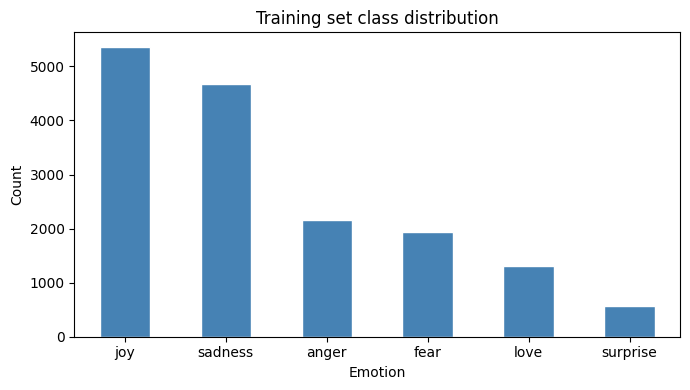

In [4]:
# Label names
label_names = train_ds.features['label'].names
print('Label names:', label_names)

# Class distribution
df_train = train_ds.to_pandas()
df_train['label_name'] = df_train['label'].apply(lambda i: label_names[i])

fig, ax = plt.subplots(figsize=(7, 4))
df_train['label_name'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Training set class distribution')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

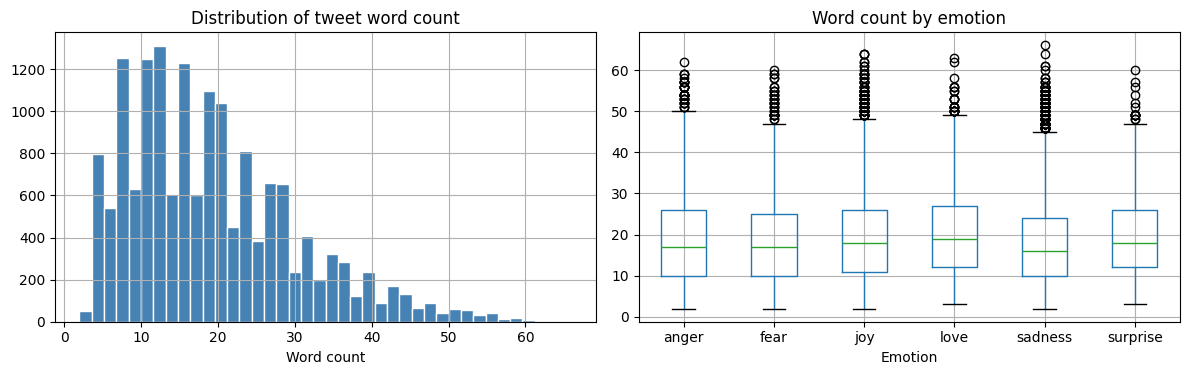

count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: num_words, dtype: float64


In [5]:
# Text length distribution
df_train['num_words'] = df_train['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_train['num_words'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of tweet word count')
axes[0].set_xlabel('Word count')

df_train.boxplot('num_words', by='label_name', ax=axes[1])
axes[1].set_title('Word count by emotion')
axes[1].set_xlabel('Emotion')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df_train['num_words'].describe())

## 2. Tokenization

### DistilBERT (`distilbert-base-uncased`)

#### Why a Transformer encoder?

Text classification is an *understanding* task: given a sentence, assign a label. This calls for a model that reads the **full sequence bidirectionally** — each token attends to every other token simultaneously — so the representation of a word is informed by what comes before *and* after it. That is exactly what a **Transformer encoder** provides.

Decoder-only models (e.g. GPT) process tokens left-to-right and are optimised for *generation*. Encoder-decoder models (e.g. T5) add a cross-attention decoder for *sequence-to-sequence* tasks. For classification we need neither; a pure encoder is the right inductive bias.

#### What is BERT / DistilBERT?

**BERT** (Bidirectional Encoder Representations from Transformers) is a transformer encoder pre-trained on massive text corpora with two self-supervised objectives: masked language modelling (predict randomly masked tokens) and next-sentence prediction. This gives it deep, bidirectional contextual representations of language.

**DistilBERT** is a distilled (compressed) version of BERT trained by knowledge distillation:
- **40 % fewer parameters** (66 M vs 110 M) and **60 % faster** inference
- Retains **97 % of BERT's language understanding** on GLUE benchmarks
- Achieved by training a 6-layer student model to mimic a 12-layer BERT teacher

The **`-base-uncased`** suffix means:
- *base* — the standard 6-layer / 768-hidden-dim / 12-head configuration (as opposed to *large*)
- *uncased* — all text is lowercased before tokenization, so `Happy` and `happy` map to the same tokens. This trades a little precision (no casing signal) for a smaller vocabulary and faster training, which is usually fine for sentiment/emotion tasks.

Architecture used here:
```
Input text
  └─► WordPiece tokenizer  → token IDs
        └─► Token embeddings + position embeddings
              └─► 6 × Transformer encoder blocks (self-attention + FFN)
                    └─► last_hidden_state  shape: (batch, seq_len, 768)
                          └─► [CLS] vector (index 0) → sentence representation
```

### Subword Tokenization — WordPiece

Raw text cannot be fed directly to a neural network. We need to map strings to integer token IDs. Three main strategies exist:

| Strategy | Vocabulary | Problem |
|---|---|---|
| **Word-level** | one ID per word | huge vocab; OOV words become `[UNK]` |
| **Character-level** | one ID per character | very short sequences but no word-level semantics |
| **Subword** | frequent words stay whole; rare words split into pieces | best of both worlds |

BERT and DistilBERT use **WordPiece**, a subword algorithm that:
1. Starts with a character-level vocabulary
2. Iteratively merges the pair of symbols that maximises the likelihood of the training corpus
3. Stops when the vocabulary reaches a target size (30 522 tokens for `distilbert-base-uncased`)

Continuation subwords are prefixed with `##` to signal they are not word-initial:

```
"unhappiness"  →  ['un', '##hap', '##pi', '##ness']
"playing"      →  ['playing']            # frequent enough to stay whole
"tokenization" →  ['token', '##ization']
```

Every sequence is also wrapped with two special tokens:
- `[CLS]` (index 101) — prepended; its final hidden state is used as the aggregate sequence representation for classification tasks
- `[SEP]` (index 102) — appended; marks the end of a segment

Because `distilbert-base-uncased` is uncased, the tokenizer **lowercases** input before splitting, so `Happy` → `['happy']` and `HAPPY` → `['happy']`.

In [6]:
# Demonstrate WordPiece subword splitting on a few tricky words
demo_words = [
    "unhappiness",
    "tokenization",
    "playing",
    "electroencephalography",
    "I feel fantastic!",
    "COVID-19",
]

# Load tokenizer early so the demo runs before the full encode step
_tok = AutoTokenizer.from_pretrained(MODEL_CKPT)

for text in demo_words:
    ids = _tok.encode(text, add_special_tokens=True)
    pieces = _tok.convert_ids_to_tokens(ids)
    print(f"{text!r:35s} → {pieces}")

'unhappiness'                       → ['[CLS]', 'un', '##ha', '##pp', '##iness', '[SEP]']
'tokenization'                      → ['[CLS]', 'token', '##ization', '[SEP]']
'playing'                           → ['[CLS]', 'playing', '[SEP]']
'electroencephalography'            → ['[CLS]', 'electro', '##ence', '##pha', '##log', '##raphy', '[SEP]']
'I feel fantastic!'                 → ['[CLS]', 'i', 'feel', 'fantastic', '!', '[SEP]']
'COVID-19'                          → ['[CLS]', 'co', '##vid', '-', '19', '[SEP]']


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

# Quick sanity check
sample = "I felt so happy today!"
tokens = tokenizer(sample, return_tensors='pt')
print('Input IDs:', tokens['input_ids'])
print('Decoded:', tokenizer.convert_ids_to_tokens(tokens['input_ids'][0].tolist()))

Input IDs: tensor([[ 101, 1045, 2371, 2061, 3407, 2651,  999,  102]])
Decoded: ['[CLS]', 'i', 'felt', 'so', 'happy', 'today', '!', '[SEP]']


In [8]:
def tokenize_batch(batch):
    return tokenizer(batch['text'], padding=True, truncation=True, max_length=128)

emotions_encoded = emotions.map(tokenize_batch, batched=True, batch_size=None)
emotions_encoded.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
print(emotions_encoded)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


## 3. Baseline — Frozen DistilBERT + Logistic Regression

We extract the `[CLS]` token hidden state from the last layer as a sentence embedding, then train a simple logistic regression on top. This requires no gradient updates through the transformer.

In [9]:
model = AutoModel.from_pretrained(MODEL_CKPT).to(DEVICE)

def extract_cls_embeddings(batch):
    inputs = {k: v.to(DEVICE) for k, v in batch.items() if k in ('input_ids', 'attention_mask')}
    with torch.no_grad():
        outputs = model(**inputs)
    # [CLS] is the first token of last_hidden_state
    cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    return {'hidden_state': cls}

emotions_encoded = emotions_encoded.map(extract_cls_embeddings, batched=True, batch_size=32)
print('New columns:', emotions_encoded['train'].column_names)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


New columns: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'hidden_state']


In [10]:
# Build feature matrices
X_train = np.array(emotions_encoded['train']['hidden_state'])
y_train = np.array(emotions_encoded['train']['label'])
X_val   = np.array(emotions_encoded['validation']['hidden_state'])
y_val   = np.array(emotions_encoded['validation']['label'])
X_test  = np.array(emotions_encoded['test']['hidden_state'])
y_test  = np.array(emotions_encoded['test']['label'])

print('X_train shape:', X_train.shape)

X_train shape: (16000, 768)


In [11]:
lr_clf = LogisticRegression(max_iter=3000, C=1.0, random_state=42)
lr_clf.fit(X_train, y_train)

val_preds = lr_clf.predict(X_val)
print(f'Validation accuracy: {accuracy_score(y_val, val_preds):.4f}')
print(classification_report(y_val, val_preds, target_names=label_names))

Validation accuracy: 0.6330
              precision    recall  f1-score   support

     sadness       0.65      0.71      0.68       550
         joy       0.71      0.80      0.75       704
        love       0.49      0.30      0.37       178
       anger       0.51      0.44      0.47       275
        fear       0.55      0.55      0.55       212
    surprise       0.54      0.27      0.36        81

    accuracy                           0.63      2000
   macro avg       0.57      0.51      0.53      2000
weighted avg       0.62      0.63      0.62      2000



Test accuracy: 0.6270


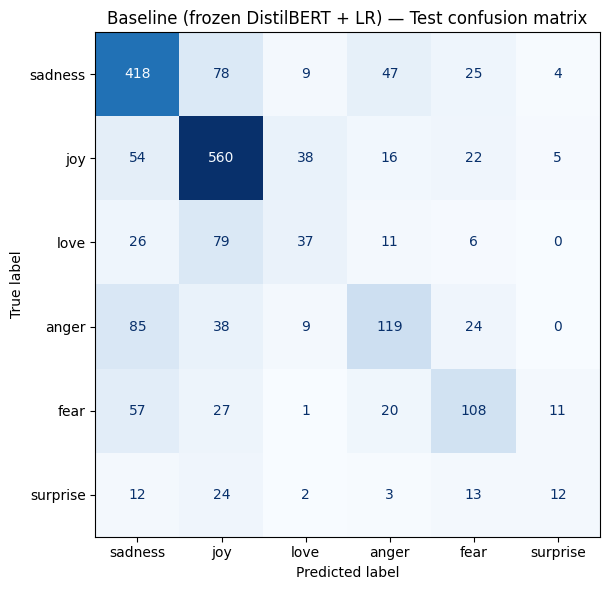

In [12]:
test_preds = lr_clf.predict(X_test)
print(f'Test accuracy: {accuracy_score(y_test, test_preds):.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=label_names,
                                        cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Baseline (frozen DistilBERT + LR) — Test confusion matrix')
plt.tight_layout()
plt.show()

### UMAP Visualisation of CLS Embeddings

After extracting the 768-dimensional `[CLS]` vector for every tweet, we want to visually inspect whether DistilBERT's representations already separate the six emotions — before any fine-tuning.

The problem: 768 dimensions cannot be plotted. **UMAP (Uniform Manifold Approximation and Projection)** is a dimensionality reduction algorithm that compresses those 768 numbers down to 2, while trying to preserve neighbourhood structure — points that were close together in 768-D should remain close in 2-D.

Each dot in the scatter plot is a tweet, coloured by its emotion label. If the clusters are well-separated, the raw DistilBERT embeddings are already meaningful for emotion and a simple logistic regression on top will work well. If everything is mixed together, a shallow classifier won't be able to separate them regardless of how it is trained.

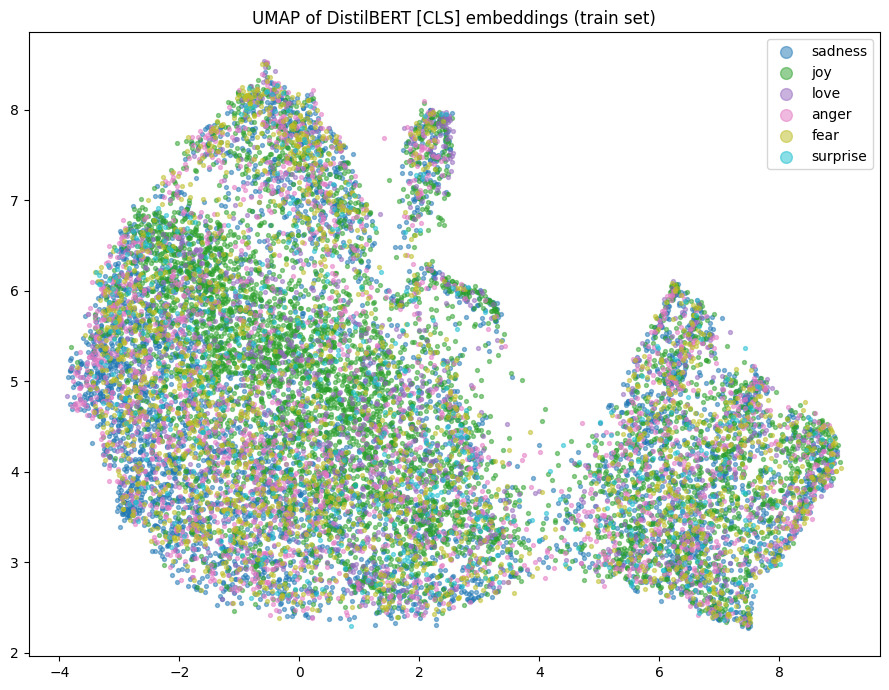

In [13]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_train_2d = reducer.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(label_names)))
for i, (name, color) in enumerate(zip(label_names, colors)):
    mask = y_train == i
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], label=name,
               alpha=0.5, s=8, color=color)
ax.legend(markerscale=3, fontsize=10)
ax.set_title('UMAP of DistilBERT [CLS] embeddings (train set)')
plt.tight_layout()
plt.show()

## 4. Fine-tuning DistilBERT end-to-end

We attach a classification head and fine-tune the full model using the HuggingFace `Trainer` API.

In [14]:
import evaluate
from transformers import DataCollatorWithPadding

num_labels = len(label_names)
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

# Re-tokenize without converting to tensors so Trainer handles collation
emotions_raw = load_dataset('dair-ai/emotion')

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=128)

tokenized = emotions_raw.map(tokenize_fn, batched=True)
tokenized = tokenized.rename_column('label', 'labels')
tokenized = tokenized.remove_columns(['text'])
tokenized.set_format('torch')

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [15]:
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

In [16]:
training_args = TrainingArguments(
    output_dir='./results/distilbert-emotion',
    num_train_epochs=2,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=50,
    report_to='none',        # disable W&B / tensorboard
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.387017,0.298901,0.910000
2,0.225219,0.207951,0.926500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.5412695426940918, metrics={'train_runtime': 242.1659, 'train_samples_per_second': 132.141, 'train_steps_per_second': 2.065, 'total_flos': 467179604923392.0, 'train_loss': 0.5412695426940918, 'epoch': 2.0})

In [17]:
# Evaluate on test set
results = trainer.evaluate(tokenized['test'])
print('Test results:', results)

Training Loss,Validation Loss,Epoch,Accuracy
0.225219,0.221199,2,0.919000


Test results: {'eval_loss': 0.2211993783712387, 'eval_accuracy': 0.919}


              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.94      0.93      0.93       695
        love       0.78      0.81      0.79       159
       anger       0.92      0.93      0.93       275
        fear       0.89      0.91      0.90       224
    surprise       0.83      0.68      0.75        66

    accuracy                           0.92      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.92      0.92      0.92      2000



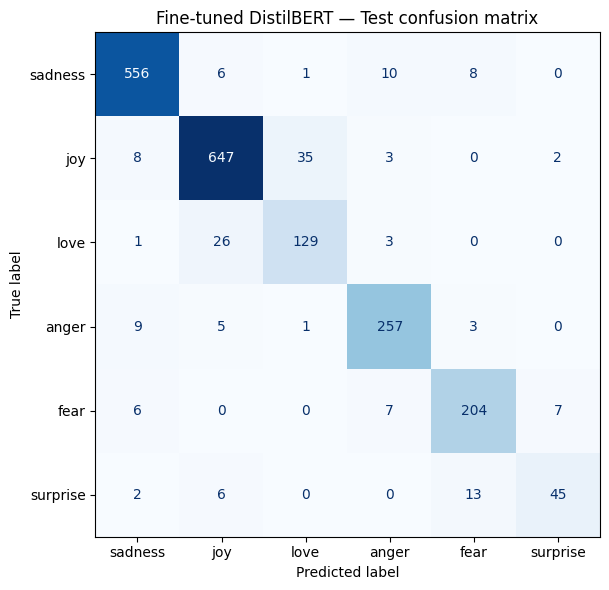

In [18]:
# Full classification report + confusion matrix
preds_output = trainer.predict(tokenized['test'])
ft_preds = np.argmax(preds_output.predictions, axis=-1)
ft_labels = preds_output.label_ids

print(classification_report(ft_labels, ft_preds, target_names=label_names))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(ft_labels, ft_preds, display_labels=label_names,
                                        cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Fine-tuned DistilBERT — Test confusion matrix')
plt.tight_layout()
plt.show()

## 5. Inference on custom text

In [19]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model=ft_model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

samples = [
    "I can't believe how amazing this day has been!",
    "I'm so angry I could scream.",
    "Everything feels pointless and empty.",
    "I'm terrified of what might happen next.",
    "I didn't expect that at all, wow!",
    "The package arrived and I feel nothing special.",
]

for text in samples:
    result = classifier(text)[0]
    print(f"{result['label']:10s} ({result['score']:.3f})  →  {text}")

surprise   (0.484)  →  I can't believe how amazing this day has been!
anger      (0.958)  →  I'm so angry I could scream.
sadness    (0.975)  →  Everything feels pointless and empty.
fear       (0.949)  →  I'm terrified of what might happen next.
surprise   (0.542)  →  I didn't expect that at all, wow!
joy        (0.972)  →  The package arrived and I feel nothing special.
